In [8]:
import pandas as pd
import numpy as np
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [9]:
df = pd.read_csv("GALAXY_DATASET/final_15000.csv")
df.head()

,dr7objid,asset_id,t01_smooth_or_features_a01_smooth_debiased,t01_smooth_or_features_a02_features_or_disk_debiased,t02_edgeon_a04_yes_debiased,t03_bar_a06_bar_debiased,t04_spiral_a08_spiral_debiased,t08_odd_feature_a24_merger_debiased,t08_odd_feature_a22_irregular_debiased
0,587722981742018657,15,0.003,0.955,0.000000,0.000000,0.733360,0.003648,0.526693
1,587722981744050315,35,0.000,0.981,0.000289,0.402361,0.998695,0.000000,0.045512
2,587722981746016481,63,0.020,0.973,0.000000,0.216366,0.995563,0.000000,0.437910
3,587722981747654761,81,0.766,0.757,0.108623,0.381713,0.926622,0.000000,0.889990
4,587722981747982465,89,0.154,0.846,0.003660,0.885386,0.839584,0.211087,0.340519


In [10]:
# 10 images are missing from the folder, drop those rows
img_folder = "Images Differing sizes/224"
valid = set(int(f.replace(".jpg", "")) for f in os.listdir(img_folder) if f.endswith(".jpg"))
df = df[df["asset_id"].isin(valid)].reset_index(drop=True)
print(len(df))  # should be 14990

14990


In [ ]:
def make_label(row, thresh=0.5):

    smooth    = row["t01_smooth_or_features_a01_smooth_debiased"]
    featured  = row["t01_smooth_or_features_a02_features_or_disk_debiased"]

    irregular=row["t08_odd_feature_24_irregular_debiased"]
    bar       = row["t03_bar_a06_bar_debiased"]
    spiral    = row["t04_spiral_a08_spiral_debiased"]
    edgeon    = row["t02_edgeon_a04_yes_debiased"]
    merger = row["t06_odd_a14_yes_debiased"]

    labels=[]
   

    if featured > smooth:
        labels.append("featured")
    else:
        labels.append("smooth")

    
    if irregular>bar:
        labels.append("irregular")

        if edgeon > thresh:
            labels.append("edge_on")

        if merger > thresh:
            labels.append("merger")
    
    else:

        if bar<thresh and spiral<thresh and edgeon<thresh and merger<thresh:
            labels.append("eliptical")
        
        else: 
        
            if bar>thresh:
                labels.append("barred_spiral")

            elif spiral>thresh:
                labels.append("spiral")

            if edgeon > thresh:
                labels.append("edge_on")

            if merger > thresh:
                labels.append("merger")

    if len(labels) == 0:
        return None
    return "_".join(labels)

df["label"] = df.apply(make_label, axis=1)
df = df.dropna(subset=["label"]).reset_index(drop=True)
print(df["label"].value_counts())

label
elliptical       6195
spiral           3423
barred_spiral    2289
edge_on          1190
Name: count, dtype: int64


In [ ]:
classes = sorted(df["label"].dropna().unique())

print(classes)
print(f"Number of classes: {len(classes)}")

class_to_idx = {c:i for i, c in enumerate(classes)}
idx_to_class = {i:c for c, i in class_to_idx.items()}

{'elliptical': 0, 'spiral': 1, 'barred_spiral': 2, 'edge_on': 3}

In [13]:
class GalaxyDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        path = os.path.join(self.img_dir, f"{int(row['asset_id'])}.jpg")
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, int(row["label_idx"])

In [14]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df["label"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["label"])
print(f"train: {len(train_df)}  val: {len(val_df)}  test: {len(test_df)}")

train: 9167  val: 1965  test: 1965


In [15]:
# imagenet mean/std since we're using pretrained models
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(360),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [18]:
train_ds = GalaxyDataset(train_df, img_folder, transform=train_tfms)
val_ds   = GalaxyDataset(val_df,   img_folder, transform=val_tfms)
test_ds  = GalaxyDataset(test_df,  img_folder, transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=0)

print(f"batches — train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}")

batches — train: 287  val: 62  test: 62


torch.Size([32, 3, 224, 224])


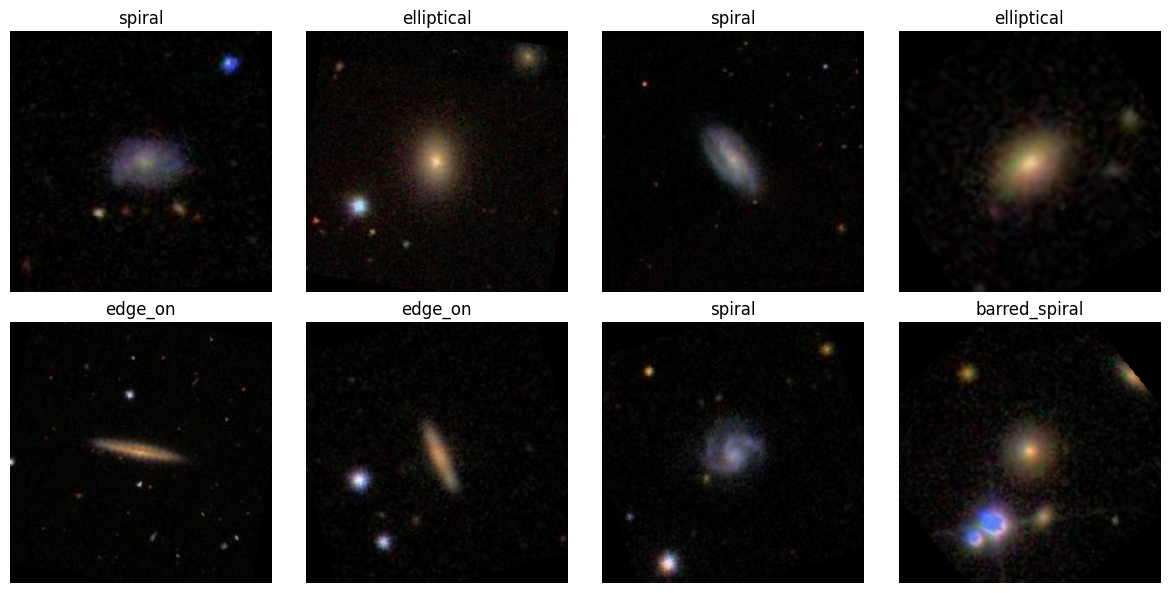

In [19]:
idx2label = {v: k for k, v in label2idx.items()}

imgs, labels = next(iter(train_loader))
print(imgs.shape)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = imgs[i].permute(1, 2, 0).numpy()
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(idx2label[labels[i].item()])
    ax.axis("off")
plt.tight_layout()
plt.show()